# Лабораторна робота №1  
## Зменшення розмірності даних
### Фролова Валерія КН-43

**Мета:** Ознайомитися з основами зменшення розмірності даних (dimensionality reduction) на прикладі зображень рукописних цифр із набору MNIST. Навчитись виконувати метод головних компонент (PCA), інтерпретувати отримані результати, оцінювати втрату інформації після проєкції та реконструкції зображень.

### 1.  Викачати та підготувати дані

In [50]:
from sklearn.datasets import fetch_openml

In [51]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

In [52]:
import numpy as np

print("Shape of matrix X:", X.shape)
print("Number of unique labels:", len(np.unique(y)))

Shape of matrix X: (70000, 784)
Number of unique labels: 10


In [53]:
import matplotlib.pyplot as plt

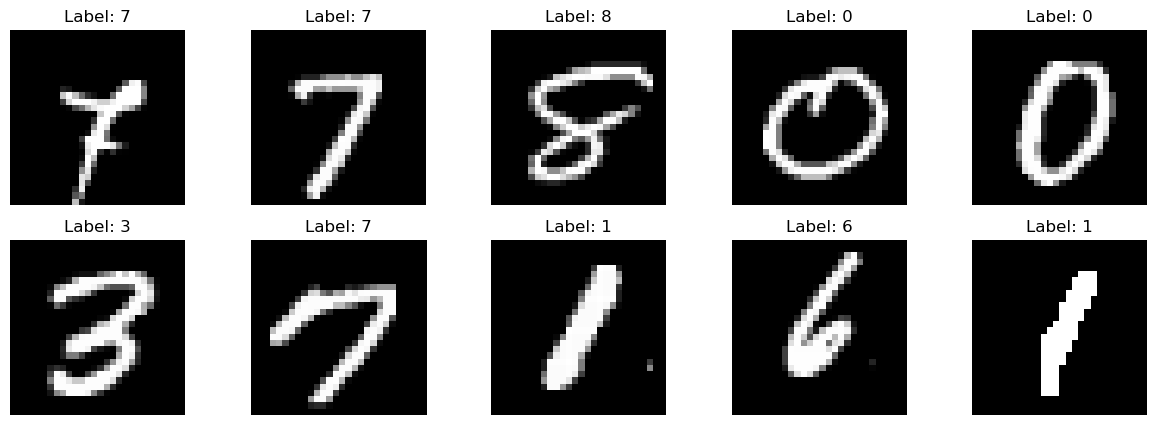

In [54]:
rand_index = np.random.choice(len(X), 10)

plt.figure(figsize=(15,5))

for i, idx in enumerate(rand_index):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y[idx]}")
    plt.axis("off")

plt.show()

## 2. Реалізувати метод головних компонент (PCA)

In [55]:
from sklearn.decomposition import PCA

In [63]:
pca = PCA(n_components=3)

X_scaled = X / 255.0

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio for each component:", pca.explained_variance_ratio_)
print("Shape of matrix after PCA:", X_pca.shape)

Explained variance ratio for each component: [0.09746116 0.07155445 0.06149531]
Shape of matrix after PCA: (70000, 3)


## 3. Візуалізувати дані у просторі перших трьох компонент

In [57]:
from mpl_toolkits.mplot3d import Axes3D

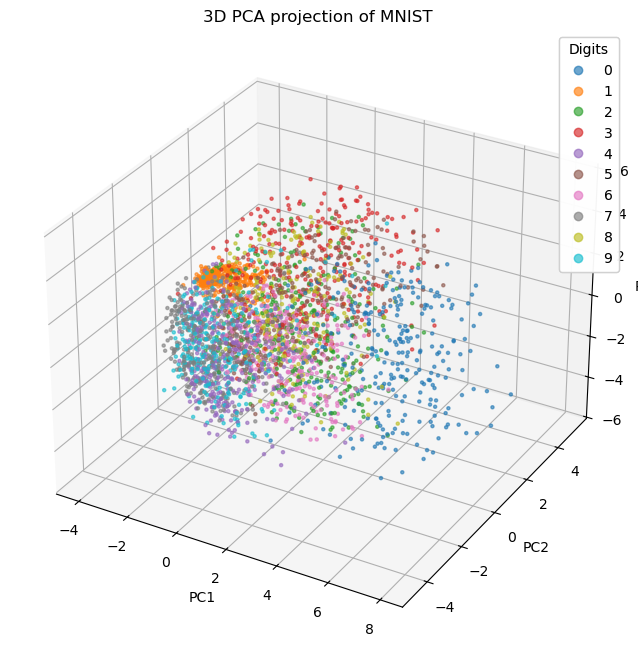

In [58]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

n_samples = 3000

colors = y[:n_samples].astype(int)

scatter = ax.scatter(
    X_pca[:n_samples,0],
    X_pca[:n_samples,1],
    X_pca[:n_samples,2],
    c=colors,
    cmap="tab10",
    s=5,
    alpha=0.6
)

ax.set_title("3D PCA projection of MNIST")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

legend1 = ax.legend(*scatter.legend_elements(), title="Digits")
ax.add_artist(legend1)

plt.show()

## 4. Реконструкція зображень після зменшення розмірності

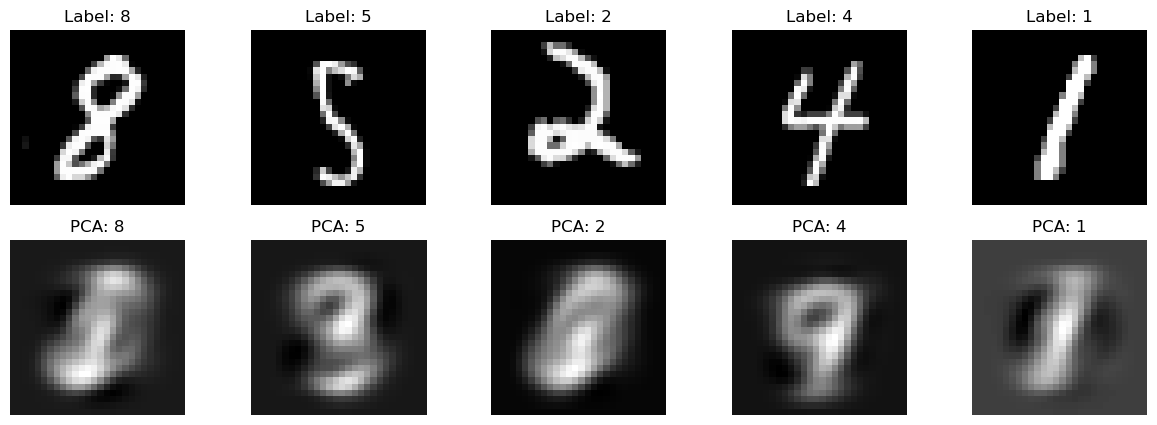

In [59]:
X_reconstructed = pca.inverse_transform(X_pca)

rand_index = np.random.choice(len(X), 5)

plt.figure(figsize=(15,5))

for i, idx in enumerate(rand_index):

    # original
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y[idx]}")
    plt.axis("off")

    # reconstructed
    plt.subplot(2, 5, i + 6)
    plt.imshow(X_reconstructed[idx].reshape(28, 28), cmap="gray")
    plt.title(f"PCA: {y[idx]}")
    plt.axis("off")

plt.show()

## 5.Проаналізувати залежність між помилкою реконструкції та кількістю компонент

In [60]:
from sklearn.metrics import mean_squared_error

components = [2, 5, 10, 20, 50, 100]

mse = []
variance = []

for k in components:

    pca = PCA(n_components=k)

    X_pca = pca.fit_transform(X_scaled)

    X_rec = pca.inverse_transform(X_pca)

    error = mean_squared_error(X_scaled, X_rec)

    mse.append(error)

    variance.append(np.sum(pca.explained_variance_ratio_))

print("Reconstruction error (MSE):", [float(x) for x in mse])
print("Explained variance:", [float(x) for x in variance])

Reconstruction error (MSE): [0.05590972155534612, 0.0448474294473716, 0.03436928361244887, 0.023904593720969754, 0.01174604982917958, 0.005721158268382203]
Explained variance: [0.16901560509373453, 0.3334340972252257, 0.4891704420709688, 0.6447067916616958, 0.825418838829715, 0.9149666084974453]


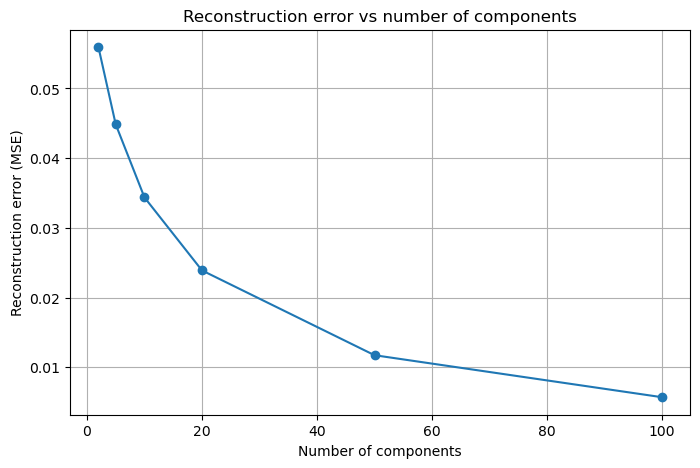

In [61]:
plt.figure(figsize=(8,5))

plt.plot(components, mse, marker="o")

plt.xlabel("Number of components")
plt.ylabel("Reconstruction error (MSE)")

plt.title("Reconstruction error vs number of components")

plt.grid(True)

plt.show()

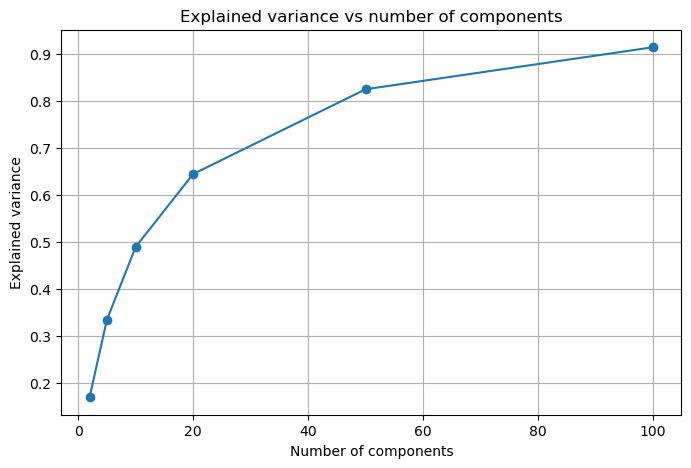

In [62]:
plt.figure(figsize=(8,5))

plt.plot(components, variance, marker="o")

plt.xlabel("Number of components")
plt.ylabel("Explained variance")

plt.title("Explained variance vs number of components")

plt.grid(True)

plt.show()

## **Висновок:**
### У ході виконання лабораторної роботи було застосовано метод головних компонент (PCA) для зменшення розмірності даних на прикладі набору MNIST. Дані було зменшено з 784 ознак до трьох головних компонент та візуалізовано у тривимірному просторі. Також було виконано реконструкцію зображень та оцінено помилку відновлення. Результати показали, що зі збільшенням кількості компонент зменшується помилка реконструкції та зростає пояснена дисперсія, що підтверджує ефективність методу PCA для зменшення розмірності даних.